In [1]:
from typing_extensions import TypedDict
from typing import List, Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

llm = init_chat_model(model="llama3.1:8B", model_provider="ollama")

free_llm = init_chat_model(model="llama3.1:8B", model_provider="ollama")
avg_llm = init_chat_model(model="gpt-4o-mini", model_provider="openai")
smart_llm = init_chat_model(model="gpt-4o", model_provider="openai")

In [2]:
class State(TypedDict):
    question: str
    difficulty: str
    answer: str
    model_used: str

class DifficultyResponse(BaseModel):
    difficulty_level: Literal["easy", "medium", "hard"]

In [3]:
def use_free_llm(state: State):
    response = free_llm.invoke(state["question"])

    return {
        "answer": response.content,
        "model_used": "ollama/llama3.1:8B"
    }


def use_avg_llm(state: State):
    response = free_llm.invoke(state["question"])

    return {
        "answer": response.content,
        "model_used": "openai/gpt-4o-mini"
    }


def use_smart_llm(state: State):
    response = free_llm.invoke(state["question"])

    return {
        "answer": response.content,
        "model_used": "openai/gpt-4o"
    }


def assess_difficulty(state: State):
    structured_llm = avg_llm.with_structured_output(DifficultyResponse)

    response = structured_llm.invoke(
        f"""
        Assess the difficulty of this question
        Question: {state["question"]}

        - EASY: Simple facts, basic definitions, yes/no answers
        - MEDIUM: Requires explanation, comparison, analysis
        - HARD: Complex reasoning, multiple steps, deep expertise.
        """
    )

    difficult_level = response.difficulty_level
    if difficult_level == 'easy':
        goto = "use_free_llm"
    elif difficult_level == "medium":
        goto = "use_avg_llm"
    elif difficult_level == "hard":
        goto = "use_smart_llm"
    else:
        print("This difficult level is not included in Literal")
        goto = "use_free_llm"

    return Command(goto=goto, update={"difficulty": difficult_level})

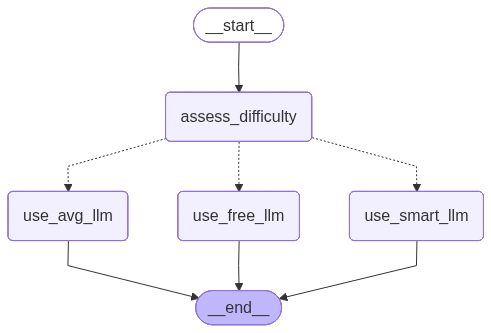

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("use_free_llm", use_free_llm)
graph_builder.add_node("use_avg_llm", use_avg_llm)
graph_builder.add_node("use_smart_llm", use_smart_llm)
graph_builder.add_node(
    "assess_difficulty",
    assess_difficulty,
    destinations=("use_free_llm", "use_avg_llm", "use_smart_llm"), # 실제 edge가 없더라도, 그래프 모형에 적용되도록 하는 속성
)

graph_builder.add_edge(START, "assess_difficulty")
graph_builder.add_edge("use_free_llm", END)
graph_builder.add_edge("use_avg_llm", END)
graph_builder.add_edge("use_smart_llm", END)

graph = graph_builder.compile()

graph

In [6]:
graph.invoke({ "question": "How to use Claude code" })

/Users/choseongyun/Documents/GitHub-SeongYun/ai-agent-master-class/workflow-architectures/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DifficultyResponse(difficulty_level='medium'), input_type=DifficultyResponse])
  return self.__pydantic_serializer__.to_python(


{'question': 'How to use Claude code',
 'difficulty': 'medium',
 'answer': 'Claude is an AI model developed by Google that allows you to generate human-like text responses. You can use Claude through various interfaces, including the official website, mobile apps, and integrations with other tools like chatbots or email clients.\n\nHere\'s a step-by-step guide on how to use Claude:\n\n**Using the Official Website**\n\n1. Go to the [Claude website](https://claudedev.com/).\n2. Click on "Try Now" to create an account or sign in if you already have one.\n3. Type your question, prompt, or topic in the text area at the top of the page.\n4. Select the language and tone you want Claude to use (e.g., formal, informal, humorous, etc.).\n5. Click on "Generate" to receive a response from Claude.\n\n**Using Mobile Apps**\n\n1. Download the Claude mobile app from the App Store or Google Play Store.\n2. Create an account or sign in if you already have one.\n3. Type your question, prompt, or topic in